YELP DATASET EDA:
-

In [3]:
# Imports and env setup

import numpy as np
import json
from collections import defaultdict, OrderedDict, Counter
from datetime import datetime
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from pathlib import Path
import os
from tqdm import tqdm

review_data_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_review.json"
business_data_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_business.json"

Check counts for review, users, and businesses



In [4]:
# Get counts

# Total review count
count = 0
with open(review_data_path, "r", encoding="utf-8") as f:
    for _ in f:
        count += 1
print(f"Review dataset row count (number of reviews) is {count}")


# Use a dict to track seen user_ids (keys are user_ids, values are ignored or counts)
user_dict = {}

with open(review_data_path, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        uid = record.get('user_id')
        # Only add to dict if we haven’t seen this user yet
        if uid not in user_dict:
            user_dict[uid] = True

unique_user_count = len(user_dict)
print(f"Unique users in review dataset is {unique_user_count}")


# Total business count
count = 0
with open(review_data_path, "r", encoding="utf-8") as f:
    for _ in f:
        count += 1
print(f"Business dataset row count (number of buinesses) is {count}")


Review dataset row count (number of reviews) is 6990280
Unique users in review dataset is 1987929
Business dataset row count (number of buinesses) is 6990280


Assess percentiles of review counts by user and business

In [5]:
review_data_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_review.json"

user_counts = defaultdict(int)
business_counts = defaultdict(int)

with open(review_data_path, "r") as f:
    for line in f:
        review = json.loads(line)
        user_counts[review["user_id"]] += 1
        business_counts[review["business_id"]] += 1

user_review_counts = np.array(list(user_counts.values()))
business_review_counts = np.array(list(business_counts.values()))

percentiles = list(range(0, 101, 10))  # 0, 10, ..., 100

print("User review count percentiles:")
for p in percentiles:
    val = np.percentile(user_review_counts, p)
    print(f"{p:>3}th percentile: {val:.1f}")

print("\nBusiness review count percentiles:")
for p in percentiles:
    val = np.percentile(business_review_counts, p)
    print(f"{p:>3}th percentile: {val:.1f}")

User review count percentiles:
  0th percentile: 1.0
 10th percentile: 1.0
 20th percentile: 1.0
 30th percentile: 1.0
 40th percentile: 1.0
 50th percentile: 1.0
 60th percentile: 2.0
 70th percentile: 2.0
 80th percentile: 3.0
 90th percentile: 6.0
100th percentile: 3048.0

Business review count percentiles:
  0th percentile: 5.0
 10th percentile: 6.0
 20th percentile: 7.0
 30th percentile: 9.0
 40th percentile: 11.0
 50th percentile: 15.0
 60th percentile: 21.0
 70th percentile: 31.0
 80th percentile: 50.0
 90th percentile: 101.0
100th percentile: 7673.0


The vast majority of users have 6 reviews or less, which could be challenging. Now let's examine the distribution of ratings. 

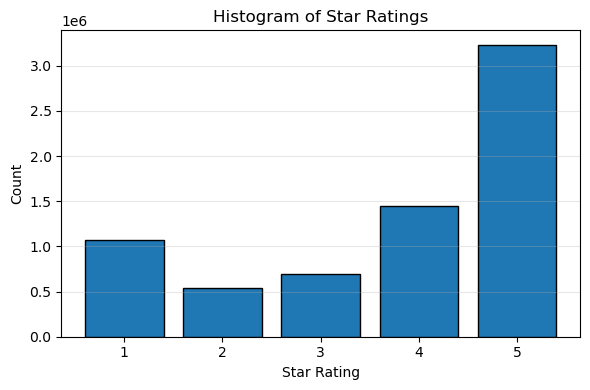

Star counts (and percentages):
  1.0: 1069561 (15.3%)
  2.0: 544240 (7.8%)
  3.0: 691934 (9.9%)
  4.0: 1452918 (20.8%)
  5.0: 3231627 (46.2%)


In [6]:
stars = []
with open(Path.cwd().parent / "Data" / "yelp_academic_dataset_review.json", 'r', encoding='utf-8') as f:
    first = f.readline().strip()
    if not first:
        raise SystemExit
    try:
        parsed = json.loads(first)
    except json.JSONDecodeError:
        raise

    # Determine format
    if isinstance(parsed, dict):
        # Could be single object or JSONL: include first and then remaining lines
        stars.append(float(parsed.get("stars", np.nan)))
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            if isinstance(obj, dict):
                stars.append(float(obj.get("stars", np.nan)))
            elif isinstance(obj, list):
                for o in obj:
                    stars.append(float(o.get("stars", np.nan)))
    elif isinstance(parsed, list):
        # Entire file is an array
        for o in parsed:
            stars.append(float(o.get("stars", np.nan)))
    else:
        # Unexpected, try to ignore
        pass

stars = [s for s in stars if not np.isnan(s)]
if not stars:
    print("No valid star ratings found.")
    raise SystemExit

# Histogram: bins centered on 1..5
bins = np.arange(0.5, 6.5, 1.0)
plt.figure(figsize=(6, 4))
plt.hist(stars, bins=bins, edgecolor='black', align='mid', rwidth=0.8)
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.title("Histogram of Star Ratings")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print counts and percentages
counts = Counter(stars)
total = sum(counts.values())
print("Star counts (and percentages):")
for star in sorted(counts):
    cnt = counts[star]
    pct = cnt / total * 100
    print(f"  {star}: {cnt} ({pct:.1f}%)")

Unfiltered ratings are very skewed to the high end. There also some skew to low end. Now let's assess time spread on when reviews were written.

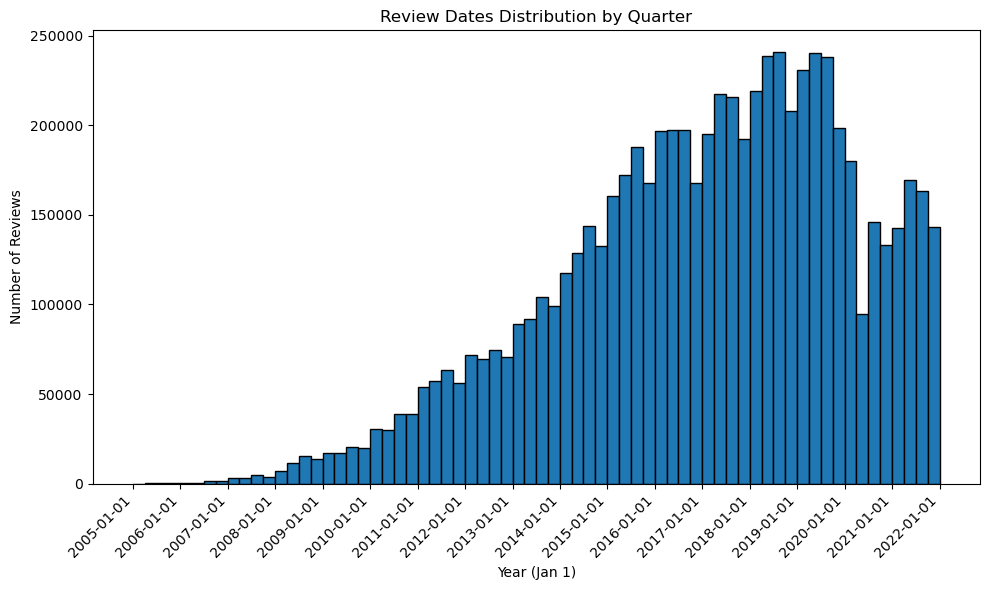

In [7]:
# --- 1) Load dates from JSON lines ---
dates = []
with open(review_data_path, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        # parse the 'date' field; adjust format if needed
        dt = datetime.strptime(record['date'], '%Y-%m-%d %H:%M:%S')
        dates.append(dt)

# ensure we have data
if not dates:
    raise ValueError("No dates found in the JSON file.")

dates.sort()
min_date, max_date = dates[0], dates[-1]

# --- 2) Compute quarterly bins ---
def start_of_quarter(dt):
    q_month = ((dt.month - 1) // 3) * 3 + 1
    return datetime(dt.year, q_month, 1)

bins = []
cur = start_of_quarter(min_date)
while cur <= max_date:
    bins.append(cur)
    next_month = cur.month + 3
    next_year  = cur.year + (next_month - 1) // 12
    next_month = ((next_month - 1) % 12) + 1
    cur = datetime(next_year, next_month, 1)

# --- 3) Year start ticks (Jan 1) ---
start_year = min_date.year
end_year   = max_date.year
year_starts = [datetime(y, 1, 1) for y in range(start_year, end_year + 1)]

# --- 4) Convert to Matplotlib numeric ---
x_vals    = mdates.date2num(dates)
bin_nums  = mdates.date2num(bins)
year_nums = mdates.date2num(year_starts)

# --- 5) Plot histogram with quarterly bins and Jan 1 labels ---
plt.figure(figsize=(10, 6))
plt.hist(x_vals, bins=bin_nums, edgecolor='black')

# set ticks at Jan 1 of each year
plt.xticks(year_nums, [dt.strftime('%Y-01-01') for dt in year_starts], rotation=45, ha='right')

plt.title("Review Dates Distribution by Quarter")
plt.xlabel("Year (Jan 1)")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

Reviews are written over many years, making time dependence a difficult problem to model. Now let's assess presence of multiple reviews on the same business by the same user as a percentage of the total review dataset.

In [8]:
# Replace with your actual file path
file_path = review_data_path

# Mapping from user_id -> set of business_ids they've reviewed
user_business = defaultdict(set)

# Counter for total revisits (user reviewing a business they've already reviewed)
revisit_count = 0

with open(review_data_path, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        uid = record.get('user_id')
        bid = record.get('business_id')
        # Check if this user has reviewed this business before
        if bid in user_business[uid]:
            revisit_count += 1
        else:
            user_business[uid].add(bid)

# Output the results
print(f"Total revisit events: {revisit_count}")

Total revisit events: 244520


There are 6,990,280 reviews in the dataset and 244,520 are rereviews (2nd or more review from a given user-business pair). There is probably some temporal effect as well since the reviews are spread over so many years, with the pandemic lockdown included as well (note the dip in 2020 that is likely from reduced traffic and stay at home mandates). To avoid increasing scope too much I'll plan on creating a time independent embedding for each user and business, and will reconcile duplicate user/business pairs by using the most recent review where necessary. This will likely increase error downstream as temporal trends are being ignored.

In [9]:

base, ext = os.path.splitext(review_data_path)
output_path = f"{base}_deduped{ext}"

# Dictionary to hold the most recent review per (user_id, business_id)
# Key: (user_id, business_id)
# Value: tuple (datetime_of_review, review_record)
latest_reviews = {}

# 1) Read and dedupe
with open(review_data_path, 'r', encoding='utf-8') as infile:
    for line in infile:
        record = json.loads(line)
        uid = record.get('user_id')
        bid = record.get('business_id')
        dt = datetime.strptime(record['date'], '%Y-%m-%d %H:%M:%S')
        key = (uid, bid)
        # Keep only the most recent review for each pair
        if key not in latest_reviews or dt > latest_reviews[key][0]:
            latest_reviews[key] = (dt, record)

# 2) Write deduped reviews back to file
with open(output_path, 'w', encoding='utf-8') as outfile:
    for _, record in latest_reviews.values():
        outfile.write(json.dumps(record) + "\n")

# 3) Output final count
filtered_count = len(latest_reviews)
print(f"Final review count after deduplication: {filtered_count}")
print(f"Deduped file written to: {output_path}")

Final review count after deduplication: 6745760
Deduped file written to: /home/symptl/github/266 Final Project/Data/yelp_academic_dataset_review_deduped.json


Since some reviews will be needed for validation as well as testing, we will need a relatively large set of reviews to characterize each user and business. We will aim for 60 reviews per user, 25 per business. We will allow overlap in the sense that reviews used on the business tower for given user review in training can be on the user tower for another user. It is not considered leakage for that particular case. It would be if that review was showing up on the business tower for the training example where it is also on the user tower (meaning that the business tower has some signal from that user when it shouldn't).

First we will identify businesses with at least 25 reviews. Then we will remove reviews from all other businesses to focus the dataset only on those businesses. We'll store this as a separate dataset that will be used on the business tower of this model. Next we will filter out users based on the businesses present in this dataset to limit reviews on the user tower to businesses that will be learned on the business tower. Since this will possibly take some businesses below 25 reviews, we will iterate back and forth between the two limits to get to two datasets that no longer reduce each other and have the specidic thresholds. This is to avoid reviews that aren't linked to any embedded meaning outside of their semantic meaning from an LLM.

We initially tried 30 per business and 75 per user in this iterative approach and ended up with no entities on either side. 25 and 60 gives me 665 users and 1188 businesses to work with. I am avoiding going lower to expand the set of entities since the training corpus will likely get shallow for each entity.

Why are users getting more reviews than businesses? The thought process is that users are more complex and have more nuances/quirks that can be learned vs. a business (multiple unrelated preferences vs. one preference being marketed to and some indication of quality). We also have the Yelp category tags on each business that are not tied to reviews, which add some formal labeling of a business' characteristics. Businesses are also allowed reviews from users not in the user tower for this reason, since it is likely much easier to describe a business is isolation than it is to characterize a user. 

We will use k-core filtering to ensure that user and business reviews for training examples are represented on both towers.

In [10]:
# File paths
review_data_path         = Path.cwd().parent / "Data" / "yelp_academic_dataset_review_deduped.json"
business_filtered_file   = Path.cwd().parent / "Data" / "business_reviews_filtered_25.json"
user_filtered_file       = Path.cwd().parent / "Data" / "yelp_academic_dataset_review_filtered_60.json"

min_biz_reviews  = 25
min_user_reviews = 60

# --- Load all reviews once ---
print("Loading reviews...")
with open(review_data_path, 'r', encoding='utf-8') as f:
    all_reviews = [json.loads(line) for line in tqdm(f, desc="Reading reviews")]

# Start with full set and do mutual k-core until stable
reviews = all_reviews
changed = True
iteration = 0

print(f"\nPerforming mutual k-core filtering: business ≥ {min_biz_reviews}, user ≥ {min_user_reviews}")
while changed:
    iteration += 1
    changed = False

    # count user reviews in current set
    user_counts = defaultdict(int)
    for r in reviews:
        user_counts[r['user_id']] += 1
    valid_users = {u for u, c in user_counts.items() if c >= min_user_reviews}

    # filter out users below threshold
    if len(valid_users) != len(user_counts):
        reviews = [r for r in reviews if r['user_id'] in valid_users]
        changed = True

    # count business reviews in current set
    biz_counts = defaultdict(int)
    for r in reviews:
        biz_counts[r['business_id']] += 1
    valid_biz = {b for b, c in biz_counts.items() if c >= min_biz_reviews}

    # filter out businesses below threshold
    if len(valid_biz) != len(biz_counts):
        reviews = [r for r in reviews if r['business_id'] in valid_biz]
        changed = True

    # report
    current_users = len({r['user_id'] for r in reviews})
    current_biz = len({r['business_id'] for r in reviews})
    print(f" Iter {iteration}: reviews={len(reviews)}, users={current_users}, businesses={current_biz}")

# --- Write final mutual k-core to both outputs ---
def write_jsonl(path, data):
    with open(path, 'w', encoding='utf-8') as f:
        for r in data:
            f.write(json.dumps(r) + '\n')

write_jsonl(user_filtered_file, reviews)
write_jsonl(business_filtered_file, reviews)

print(f"\nWrote {len(reviews)} reviews to {user_filtered_file}")
print(f"Unique users:     {len({r['user_id'] for r in reviews})}")
print(f"Unique businesses:{len({r['business_id'] for r in reviews})}")
print(f"\nAlso wrote same mutual-core set to {business_filtered_file} for consistency.")

Loading reviews...


Reading reviews: 6745760it [00:21, 317103.45it/s]



Performing mutual k-core filtering: business ≥ 25, user ≥ 60
 Iter 1: reviews=574538, users=8945, businesses=10348
 Iter 2: reviews=277395, users=3354, businesses=5449
 Iter 3: reviews=180745, users=2091, businesses=3642
 Iter 4: reviews=134502, users=1487, businesses=2697
 Iter 5: reviews=106652, users=1171, businesses=2113
 Iter 6: reviews=90221, users=979, businesses=1758
 Iter 7: reviews=76776, users=825, businesses=1404
 Iter 8: reviews=69524, users=710, businesses=1210
 Iter 9: reviews=68451, users=670, businesses=1193
 Iter 10: reviews=68036, users=665, businesses=1188
 Iter 11: reviews=68036, users=665, businesses=1188

Wrote 68036 reviews to /home/symptl/github/266 Final Project/Data/yelp_academic_dataset_review_filtered_60.json
Unique users:     665
Unique businesses:1188

Also wrote same mutual-core set to /home/symptl/github/266 Final Project/Data/business_reviews_filtered_25.json for consistency.


My hypothesis is that the majority of these reviews will be concentrated around a handful of very large cities since they are all prolific Yelpers and the businesses are also getting a high volume of reviews. So we'll analyze the cities/states where the businesses in question are located.



In [11]:
# File paths (update these to your actual file locations)
review_data_path   = Path.cwd().parent / "Data" / "business_reviews_filtered_25.json"
business_data_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_business.json"

# 1) Count reviews per business_id
business_review_counts = defaultdict(int)
with open(review_data_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Counting reviews per business"):
        record = json.loads(line)
        biz_id = record.get('business_id')
        if biz_id:
            business_review_counts[biz_id] += 1

# 2) Map business_id -> "City, ST"
business_location = {}
with open(business_data_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Reading business locations"):
        record = json.loads(line)
        biz_id = record.get('business_id')
        city   = record.get('city', '').strip()
        state  = record.get('state', '').strip()
        if biz_id and city and state:
            city_state = f"{city}, {state}"
            business_location[biz_id] = city_state

# 3) Aggregate review counts by city_state
city_state_counts = defaultdict(int)
missing_loc = 0

for biz_id, count in business_review_counts.items():
    loc = business_location.get(biz_id)
    if loc:
        city_state_counts[loc] += count
    else:
        missing_loc += 1

# 4) Output the results
print(f"Aggregated review counts for {len(city_state_counts)} city/state combos.")
if missing_loc:
    print(f"Warning: {missing_loc} businesses had no location mapping and were skipped.")

# Example: print top 20 city/state by review count
print("\nTop 50 city/state by total reviews:")
for city_state, total in sorted(city_state_counts.items(), key=lambda x: x[1], reverse=True)[:50]:
    print(f"{city_state}: {total}")

Counting reviews per business: 68036it [00:00, 376414.10it/s]
Reading business locations: 150346it [00:00, 248577.58it/s]

Aggregated review counts for 29 city/state combos.

Top 50 city/state by total reviews:
Philadelphia, PA: 65969
Cherry Hill, NJ: 387
Collingswood, NJ: 225
King of Prussia, PA: 129
Conshohocken, PA: 114
East Norriton, PA: 94
Media, PA: 92
Ardmore, PA: 83
New Orleans, LA: 81
King Of Prussia, PA: 77
Wayne, PA: 70
Manayunk, PA: 67
Westmont, NJ: 61
Kennett Square, PA: 60
Plymouth Meeting, PA: 57
Camden, NJ: 56
Downingtown, PA: 43
Wynnewood, PA: 42
Upper Darby, PA: 40
Elkins Park, PA: 33
Lansdowne, PA: 31
Haddon Township, NJ: 31
Maple Shade, NJ: 31
Huntingdon Valley, PA: 31
Glen Mills, PA: 28
Cinnaminson, NJ: 27
Pottstown, PA: 26
Pennsauken, NJ: 26
Merion Station, PA: 25


In [12]:
# File paths (update these to your actual file locations)
review_data_path   = Path.cwd().parent / "Data" / "yelp_academic_dataset_review_filtered_60.json"
business_data_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_business.json"

# 1) Count reviews per business_id
business_review_counts = defaultdict(int)
with open(review_data_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Counting reviews per business"):
        record = json.loads(line)
        biz_id = record.get('business_id')
        if biz_id:
            business_review_counts[biz_id] += 1

# 2) Map business_id -> "City, ST"
business_location = {}
with open(business_data_path, 'r', encoding='utf-8') as f:
    for line in tqdm(f, desc="Reading business locations"):
        record = json.loads(line)
        biz_id = record.get('business_id')
        city   = record.get('city', '').strip()
        state  = record.get('state', '').strip()
        if biz_id and city and state:
            city_state = f"{city}, {state}"
            business_location[biz_id] = city_state

# 3) Aggregate review counts by city_state
city_state_counts = defaultdict(int)
missing_loc = 0

for biz_id, count in business_review_counts.items():
    loc = business_location.get(biz_id)
    if loc:
        city_state_counts[loc] += count
    else:
        missing_loc += 1

# 4) Output the results
print(f"Aggregated review counts for {len(city_state_counts)} city/state combos.")
if missing_loc:
    print(f"Warning: {missing_loc} businesses had no location mapping and were skipped.")

# Example: print top 20 city/state by review count
print("\nTop 50 city/state by total reviews:")
for city_state, total in sorted(city_state_counts.items(), key=lambda x: x[1], reverse=True)[:50]:
    print(f"{city_state}: {total}")

Counting reviews per business: 68036it [00:00, 376086.19it/s]
Reading business locations: 150346it [00:00, 248725.34it/s]

Aggregated review counts for 29 city/state combos.

Top 50 city/state by total reviews:
Philadelphia, PA: 65969
Cherry Hill, NJ: 387
Collingswood, NJ: 225
King of Prussia, PA: 129
Conshohocken, PA: 114
East Norriton, PA: 94
Media, PA: 92
Ardmore, PA: 83
New Orleans, LA: 81
King Of Prussia, PA: 77
Wayne, PA: 70
Manayunk, PA: 67
Westmont, NJ: 61
Kennett Square, PA: 60
Plymouth Meeting, PA: 57
Camden, NJ: 56
Downingtown, PA: 43
Wynnewood, PA: 42
Upper Darby, PA: 40
Elkins Park, PA: 33
Lansdowne, PA: 31
Haddon Township, NJ: 31
Maple Shade, NJ: 31
Huntingdon Valley, PA: 31
Glen Mills, PA: 28
Cinnaminson, NJ: 27
Pottstown, PA: 26
Pennsauken, NJ: 26
Merion Station, PA: 25


Takeaways: With the filtering criteria I laid out, the datasets for both towers are identical (in retrospect, this is actually by design). Likely because of the filtering logic where no reviews on either tower aren't without an association on the opposite tower, virtually all reviews are clustered around Philadelphia. There are some reviews for businesses in the surrounding areas in NJ and PA, which is not surprising considering the proximity. Going forward, we will treat the review files as equal and use only one until we need to pool uniquely for features on each tower.

Let's reexamine the time spread on reviews from both the business and user tower again and see how they look.

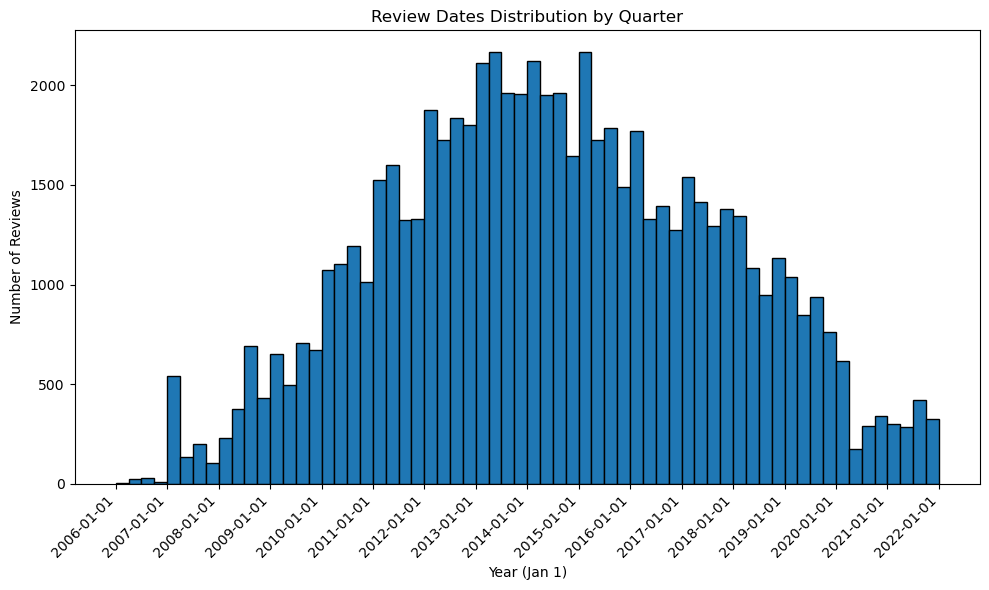

In [13]:
review_data_path   = Path.cwd().parent / "Data" / "yelp_academic_dataset_review_filtered_60.json"

# --- 1) Load dates from JSON lines ---
dates = []
with open(review_data_path, 'r', encoding='utf-8') as f:
    for line in f:
        record = json.loads(line)
        # parse the 'date' field; adjust format if needed
        dt = datetime.strptime(record['date'], '%Y-%m-%d %H:%M:%S')
        dates.append(dt)

# ensure we have data
if not dates:
    raise ValueError("No dates found in the JSON file.")

dates.sort()
min_date, max_date = dates[0], dates[-1]

# --- 2) Compute quarterly bins ---
def start_of_quarter(dt):
    q_month = ((dt.month - 1) // 3) * 3 + 1
    return datetime(dt.year, q_month, 1)

bins = []
cur = start_of_quarter(min_date)
while cur <= max_date:
    bins.append(cur)
    next_month = cur.month + 3
    next_year  = cur.year + (next_month - 1) // 12
    next_month = ((next_month - 1) % 12) + 1
    cur = datetime(next_year, next_month, 1)

# --- 3) Year start ticks (Jan 1) ---
start_year = min_date.year
end_year   = max_date.year
year_starts = [datetime(y, 1, 1) for y in range(start_year, end_year + 1)]

# --- 4) Convert to Matplotlib numeric ---
x_vals    = mdates.date2num(dates)
bin_nums  = mdates.date2num(bins)
year_nums = mdates.date2num(year_starts)

# --- 5) Plot histogram with quarterly bins and Jan 1 labels ---
plt.figure(figsize=(10, 6))
plt.hist(x_vals, bins=bin_nums, edgecolor='black')

# set ticks at Jan 1 of each year
plt.xticks(year_nums, [dt.strftime('%Y-01-01') for dt in year_starts], rotation=45, ha='right')

plt.title("Review Dates Distribution by Quarter")
plt.xlabel("Year (Jan 1)")
plt.ylabel("Number of Reviews")
plt.tight_layout()
plt.show()

Takeaways: The review data is substantially different and now centered at around 2014. But still too much spread over time to be used as a time series application. Besides the greatly increased scope, it also makes reviews very sparse until near the later half of the timespan.

SBERT models seem to be the best candidates for summarizing each of these reviews in a single embedding vector (encoder only models). These have a 512 token limit by default. Let's see how many tokens we have in our reviews on both towers.

In [14]:
from transformers import AutoTokenizer

# 1) Configuration
# Path to your JSON-lines file of reviews
review_data_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_review_filtered_60.json"

# Choose a tokenizer: BERT or SBERT
# For BERT:
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
# Or for SBERT (sentence-transformers):
# tokenizer = AutoTokenizer.from_pretrained("sentence-transformers/all-MiniLM-L6-v2")

# 2) Tokenize and count
token_counts = []
with open(review_data_path, "r", encoding="utf-8") as f:
    for line in f:
        review = json.loads(line)
        text = review.get("text", "")
        # Encode without truncation to get full token count
        tokens = tokenizer.encode(text, add_special_tokens=True)
        token_counts.append(len(tokens))

# 3) Compute statistics
token_counts = np.array(token_counts)
max_tokens = int(token_counts.max())
# Percentile of 512 tokens: fraction of reviews with length <= 512
pct_512 = float((token_counts <= 512).sum() / len(token_counts) * 100)

# 4) Output results
print(f"Maximum token count: {max_tokens}")
print(f"Percentage of reviews ≤ 512 tokens: {pct_512:.2f}%")

Token indices sequence length is longer than the specified maximum sequence length for this model (522 > 512). Running this sequence through the model will result in indexing errors


Maximum token count: 1265
Percentage of reviews ≤ 512 tokens: 95.84%


Let's examine the distribution of ratings now that we have narrowed down the review text according to our assumptions.

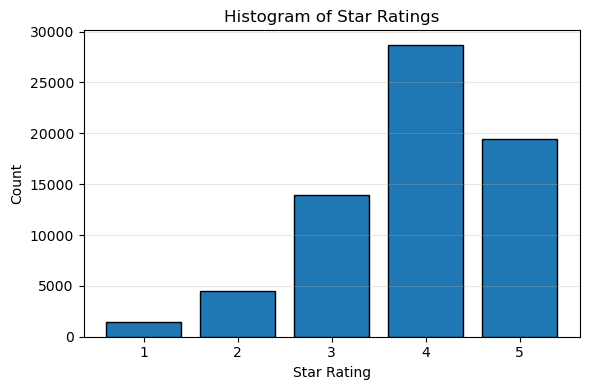

Star counts (and percentages):
  1.0: 1429 (2.1%)
  2.0: 4514 (6.6%)
  3.0: 13969 (20.5%)
  4.0: 28687 (42.2%)
  5.0: 19437 (28.6%)


In [15]:
stars = []
with open(Path.cwd().parent / "Data" / "yelp_academic_dataset_review_filtered_60.json", 'r', encoding='utf-8') as f:
    first = f.readline().strip()
    if not first:
        raise SystemExit
    try:
        parsed = json.loads(first)
    except json.JSONDecodeError:
        raise

    # Determine format
    if isinstance(parsed, dict):
        # Could be single object or JSONL: include first and then remaining lines
        stars.append(float(parsed.get("stars", np.nan)))
        for line in f:
            line = line.strip()
            if not line:
                continue
            try:
                obj = json.loads(line)
            except json.JSONDecodeError:
                continue
            if isinstance(obj, dict):
                stars.append(float(obj.get("stars", np.nan)))
            elif isinstance(obj, list):
                for o in obj:
                    stars.append(float(o.get("stars", np.nan)))
    elif isinstance(parsed, list):
        # Entire file is an array
        for o in parsed:
            stars.append(float(o.get("stars", np.nan)))
    else:
        # Unexpected, try to ignore
        pass

stars = [s for s in stars if not np.isnan(s)]
if not stars:
    print("No valid star ratings found.")
    raise SystemExit

# Histogram: bins centered on 1..5
bins = np.arange(0.5, 6.5, 1.0)
plt.figure(figsize=(6, 4))
plt.hist(stars, bins=bins, edgecolor='black', align='mid', rwidth=0.8)
plt.xticks([1, 2, 3, 4, 5])
plt.xlabel("Star Rating")
plt.ylabel("Count")
plt.title("Histogram of Star Ratings")
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# Print counts and percentages
counts = Counter(stars)
total = sum(counts.values())
print("Star counts (and percentages):")
for star in sorted(counts):
    cnt = counts[star]
    pct = cnt / total * 100
    print(f"  {star}: {cnt} ({pct:.1f}%)")


It is clear that we have a not insignificant number of user tower reviews that go over the default token limit with a max token count of 1265. The business tower reviews are identical and produce the same results.

Filtering out low volume users has possibly taken away the less nuanced reviews that are clearly negative or positive. It also seems that filtering for more prolific users has made the problem significantly more difficult, as the distributions remain concentrated but without the bipolar nature of the unfiltered distribution. There will likely be very few simple recommendations.


We will follow a structured approach in experimenting with data/model structures, outlined below:

- Generate a single embedding for each review with progressively higher capacity models
- Experiment with concatenating the "tags" field in business attributes as opposed to simply pooling it as another review. It will be encoded in the same manner as the reviews.
- Try having the prediction head just be a dot product of the tower compression layer, so that the embeddings from projection layers of similar entities are pushed together. Compare with a traditional FFNN.

We will now remove all fields that aren't relevant to our approach, to minimize data size.

In [16]:
input_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_review_filtered_60.json"        
output_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_review_filtered_60_trimmed.json"         # Output path for cleaned file

ordered_keys = ["review_id", "user_id", "business_id", "stars", "text"]

with open(input_path, "r") as infile, open(output_path, "w") as outfile:
    for line in infile:
        try:
            review = json.loads(line)
            trimmed = OrderedDict((k, review[k]) for k in ordered_keys if k in review)
            json.dump(trimmed, outfile)
            outfile.write("\n")
        except json.JSONDecodeError:
            continue

From the business metadata, we are only keeping the category tags, name, city, state, and the business id's to map back to the relevant entity. Most of the other data is around location, payment, and hours which are not particularly relevant here. There is also a star rating for the business as a whole but it is lower resolution than what could be calculated by taking an average of the associated reviews or what will be learned. Basically it's what is displayed on the Yelp UI and only goes as granular as half a star. We'll also filter this side file based on the businesses present in the review corpus for the business tower. 

Newline characters ("\n") tend to be handled well by tokenizers but we'll remove them just in case since we're not expecting any meaningful signal with those.

In [17]:
input_path = Path.cwd().parent / "Data" / "yelp_academic_dataset_review_filtered_60_trimmed.json" 
output_path = Path.cwd().parent / "Data" / "user_tower_reviews_final.json" 

with open(input_path, "r", encoding="utf-8") as infile, open(output_path, "w", encoding="utf-8") as outfile:
    for line in infile:
        try:
            data = json.loads(line)
            if "text" in data and isinstance(data["text"], str):
                data["text"] = data["text"].replace("\n", " ").strip()
            json.dump(data, outfile, ensure_ascii=False)
            outfile.write("\n")
        except json.JSONDecodeError:
            continue 

The processed and trimmed files were uploaded to Colab, where different versions were produced with different different encoders and their respective tokenizers. Each scheme was stored as a separate set of files. They were then converted into vectors with the models desribed above (word2vec, bert, and sbert (384 dimension versions)).